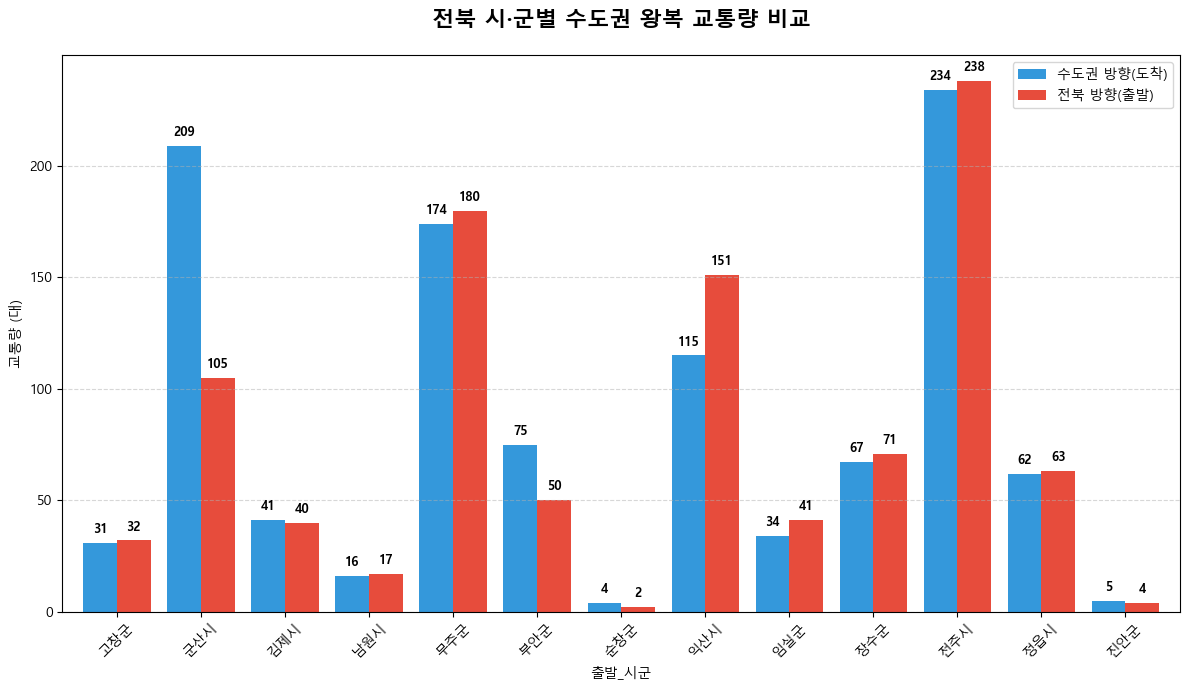

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_jeonbuk_to_metropolitan_short():
    # 1. 폰트 설정 및 데이터 로드
    plt.rc('font', family='Malgun Gothic')
    df = pd.read_csv('전북_시군별_교통량(수도권, 시군구).csv', index_col='출발_시군', encoding='utf-8-sig')

    # 2. 그래프 생성 및 기본 설정
    ax = df[['도착지방향총교통량', '출발지방향총교통량']].plot(kind='bar', figsize=(12, 7), width=0.8, color=['#3498db', '#e74c3c'])
    
    # 3. 그래프 꾸미기
    plt.title('전북 시·군별 수도권 왕복 교통량 비교', fontsize=16, fontweight='bold', pad=20)
    plt.legend(['수도권 방향(도착)', '전북 방향(출발)'], loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.ylabel('교통량 (대)')

    # 4. 숫자 표시
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('전북_수도권_교통량_현황_그래프.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_jeonbuk_to_metropolitan_short()

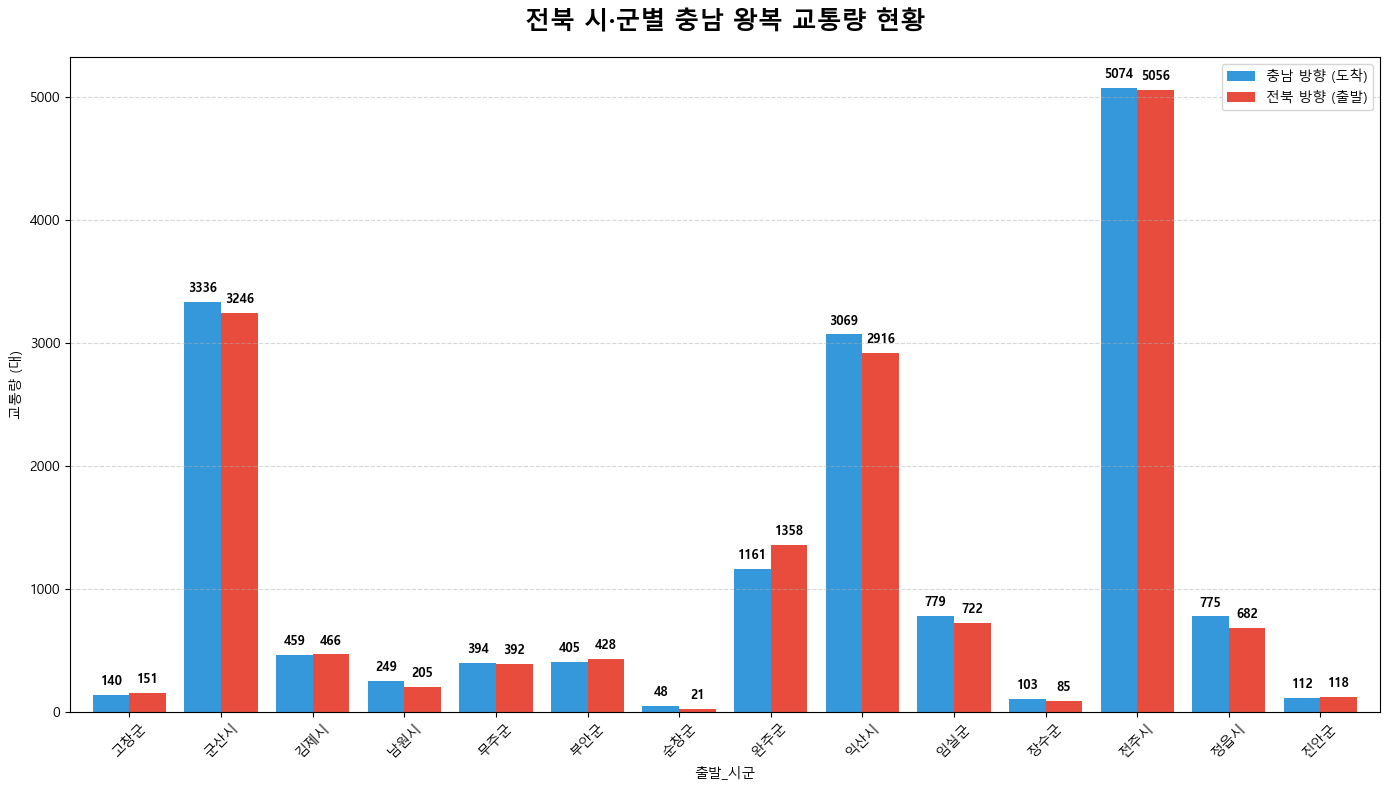

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_jeonbuk_to_chungnam_short():
    # 1. 환경 설정 및 데이터 로드
    plt.rc('font', family='Malgun Gothic')
    df = pd.read_csv('전북_시군별_교통량(충남, 시군구).csv', index_col='출발_시군', encoding='utf-8-sig')

    # 2. 그래프 생성
    ax = df[['도착지방향_교통량합계', '출발지방향_교통량합계']].plot(kind='bar', figsize=(14, 8), width=0.8, color=['#3498db', '#e74c3c'])
    
    # 3. 디자인 설정
    plt.title('전북 시·군별 충남 왕복 교통량 현황', fontsize=18, fontweight='bold', pad=20)
    plt.legend(['충남 방향 (도착)', '전북 방향 (출발)'], loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.ylabel('교통량 (대)')

    # 4. 숫자 레이블링
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('전북_충남_교통량_현황_그래프_통일.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_jeonbuk_to_chungnam_short()

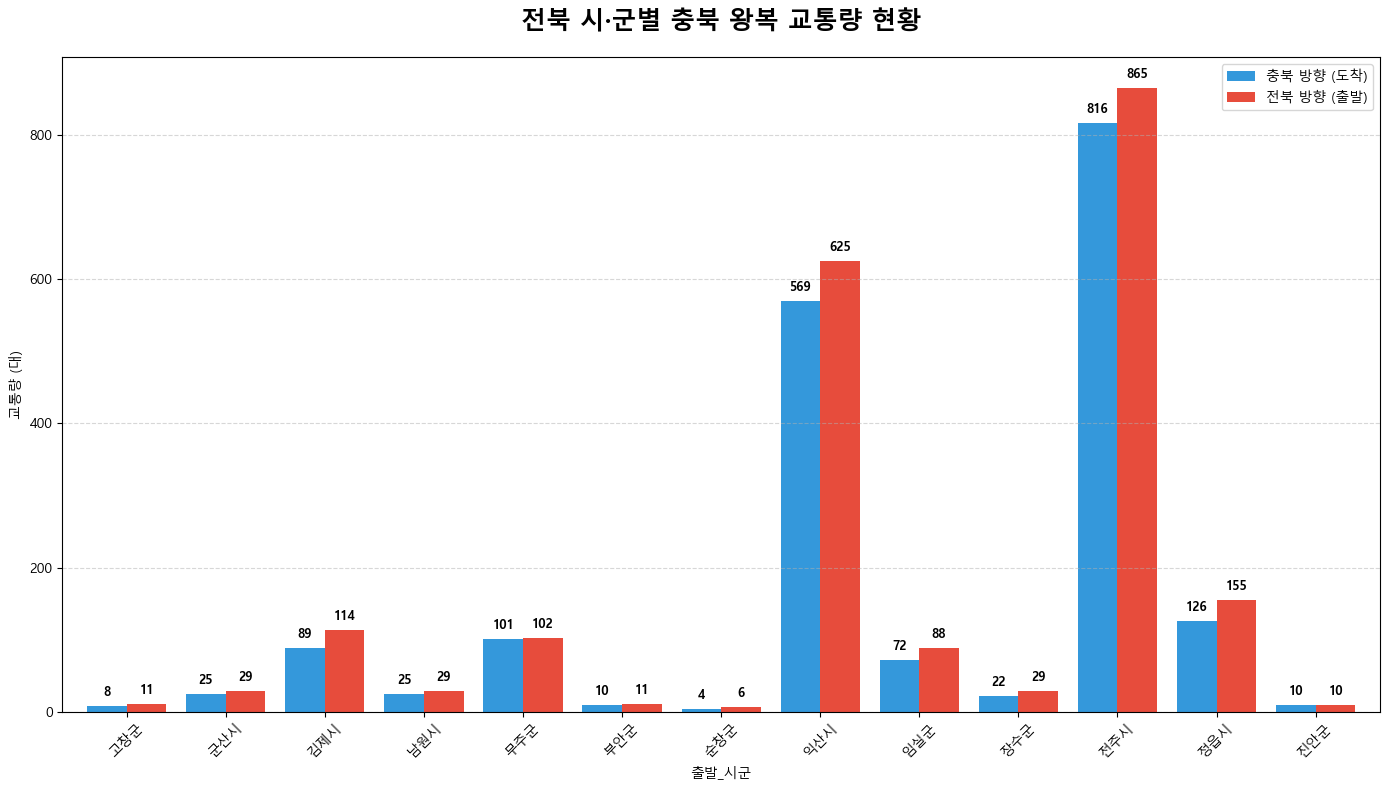

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_jeonbuk_to_chungbuk_short():
    # 1. 환경 설정 및 데이터 로드
    plt.rc('font', family='Malgun Gothic')
    df = pd.read_csv('전북_시군별_교통량(충북, 시군구).csv', index_col='출발_시군', encoding='utf-8-sig')

    # 2. 그래프 생성 및 기본 설정
    ax = df[['도착지방향_교통량합계', '출발지방향_교통량합계']].plot(kind='bar', figsize=(14, 8), width=0.8, color=['#3498db', '#e74c3c'])
    
    # 3. 디자인 설정
    plt.title('전북 시·군별 충북 왕복 교통량 현황', fontsize=18, fontweight='bold', pad=20)
    plt.legend(['충북 방향 (도착)', '전북 방향 (출발)'], loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.ylabel('교통량 (대)')

    # 4. 숫자 표시
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('전북_충북_교통량_현황_그래프_통일.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_jeonbuk_to_chungbuk_short()

✅ 연도별 파이차트가 '산업별_연도별_비중_파이차트.png'로 저장되었습니다.


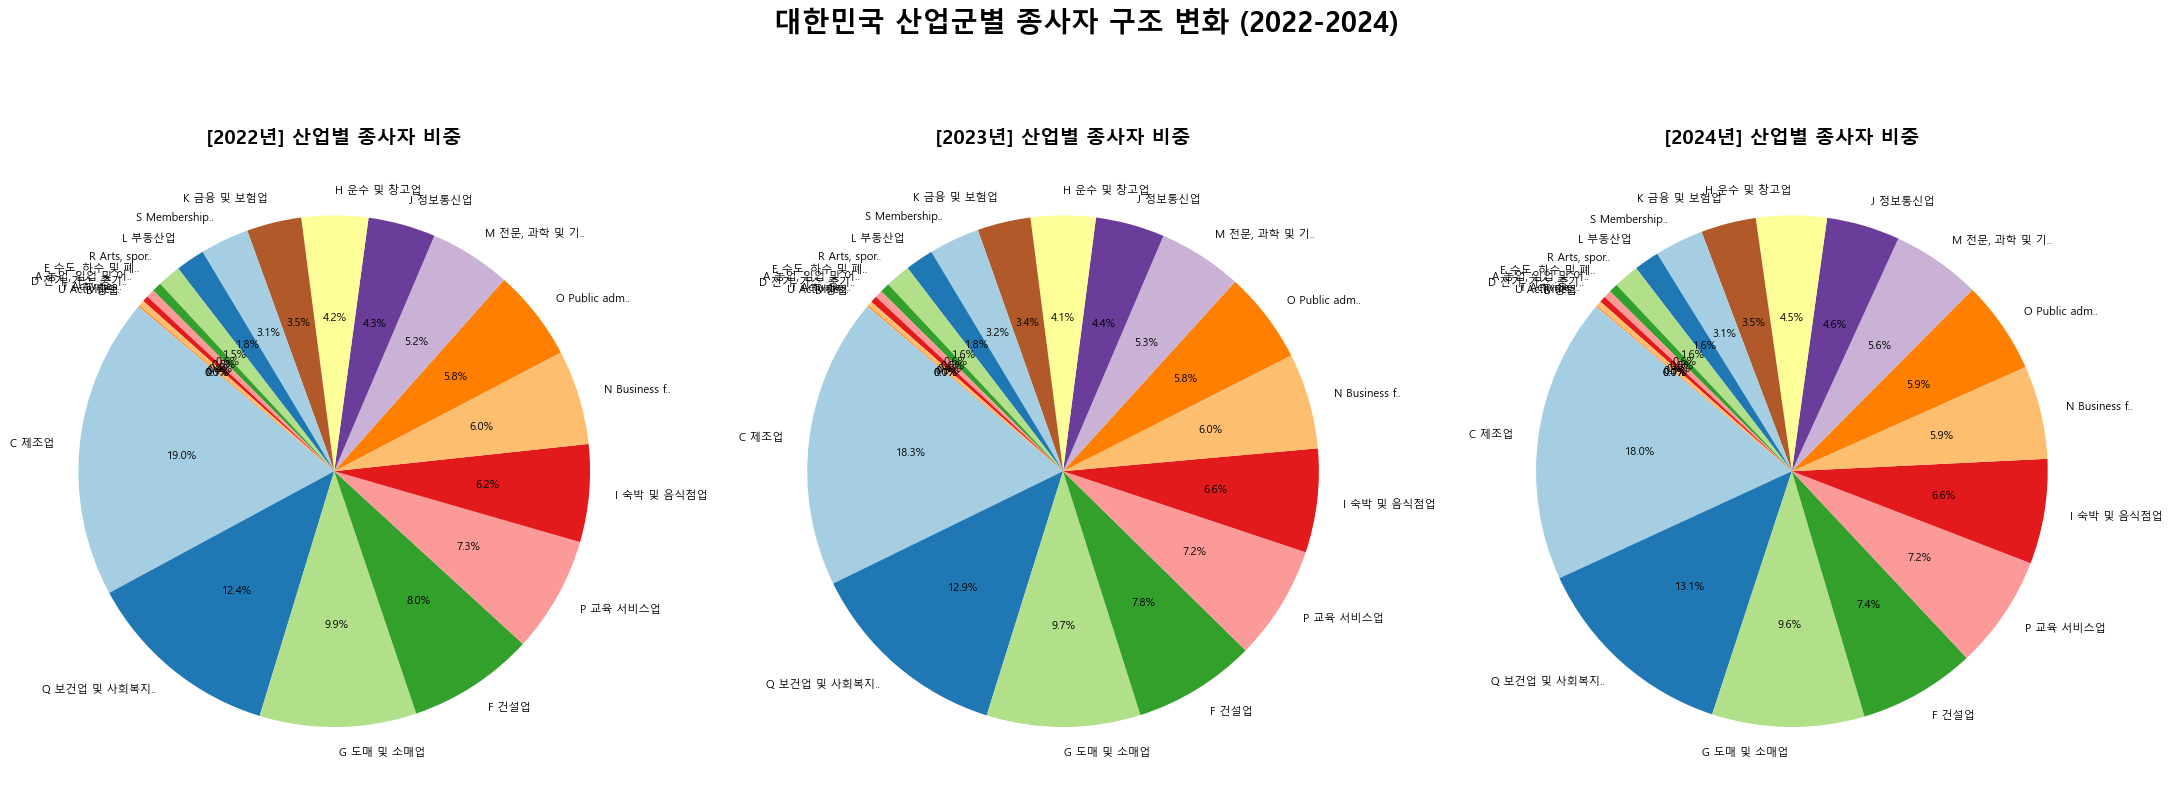

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_yearly_industry_pies():
    # 1. 데이터 불러오기
    file_name = '산업별_연도별_원지수_추출.csv'
    try:
        df = pd.read_csv(file_name, encoding='utf-8-sig')
    except:
        df = pd.read_csv(file_name, encoding='cp949')

    # 2.데이터 정제: 21개 주요 산업 필터링
    df_clean = df[df['산업별'].str.contains(r'^[A-U]\s', regex=True)].copy()
    
    # 3. 그래프 설정 (한글 폰트)
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

    # 4. 3개의 서브플롯 생성 (2022, 2023, 2024)
    years = ['2022년', '2023년', '2024년']
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    

    labels = [label[:12] + '..' if len(label) > 12 else label for label in df_clean['산업별']]

    for i, year in enumerate(years):
        col_name = f"{year} 원지수"
        values = df_clean[col_name]
        
        # 파이차트 그리기
        axes[i].pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
                    colors=plt.cm.Paired.colors, textprops={'fontsize': 8})
        axes[i].set_title(f'[{year}] 산업별 종사자 비중', fontsize=14, fontweight='bold')

    plt.suptitle('대한민국 산업군별 종사자 구조 변화 (2022-2024)', fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()

    # 5. 결과 저장 및 출력
    output_img = '산업별_연도별_비중_파이차트.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ 연도별 파이차트가 '{output_img}'로 저장되었습니다.")
    plt.show()

if __name__ == "__main__":
    plot_yearly_industry_pies()

✅ 2% 미만 항목이 '기타'로 통합된 파이차트가 '산업별_연도별_비중_파이차트_그룹화.png'로 저장되었습니다.


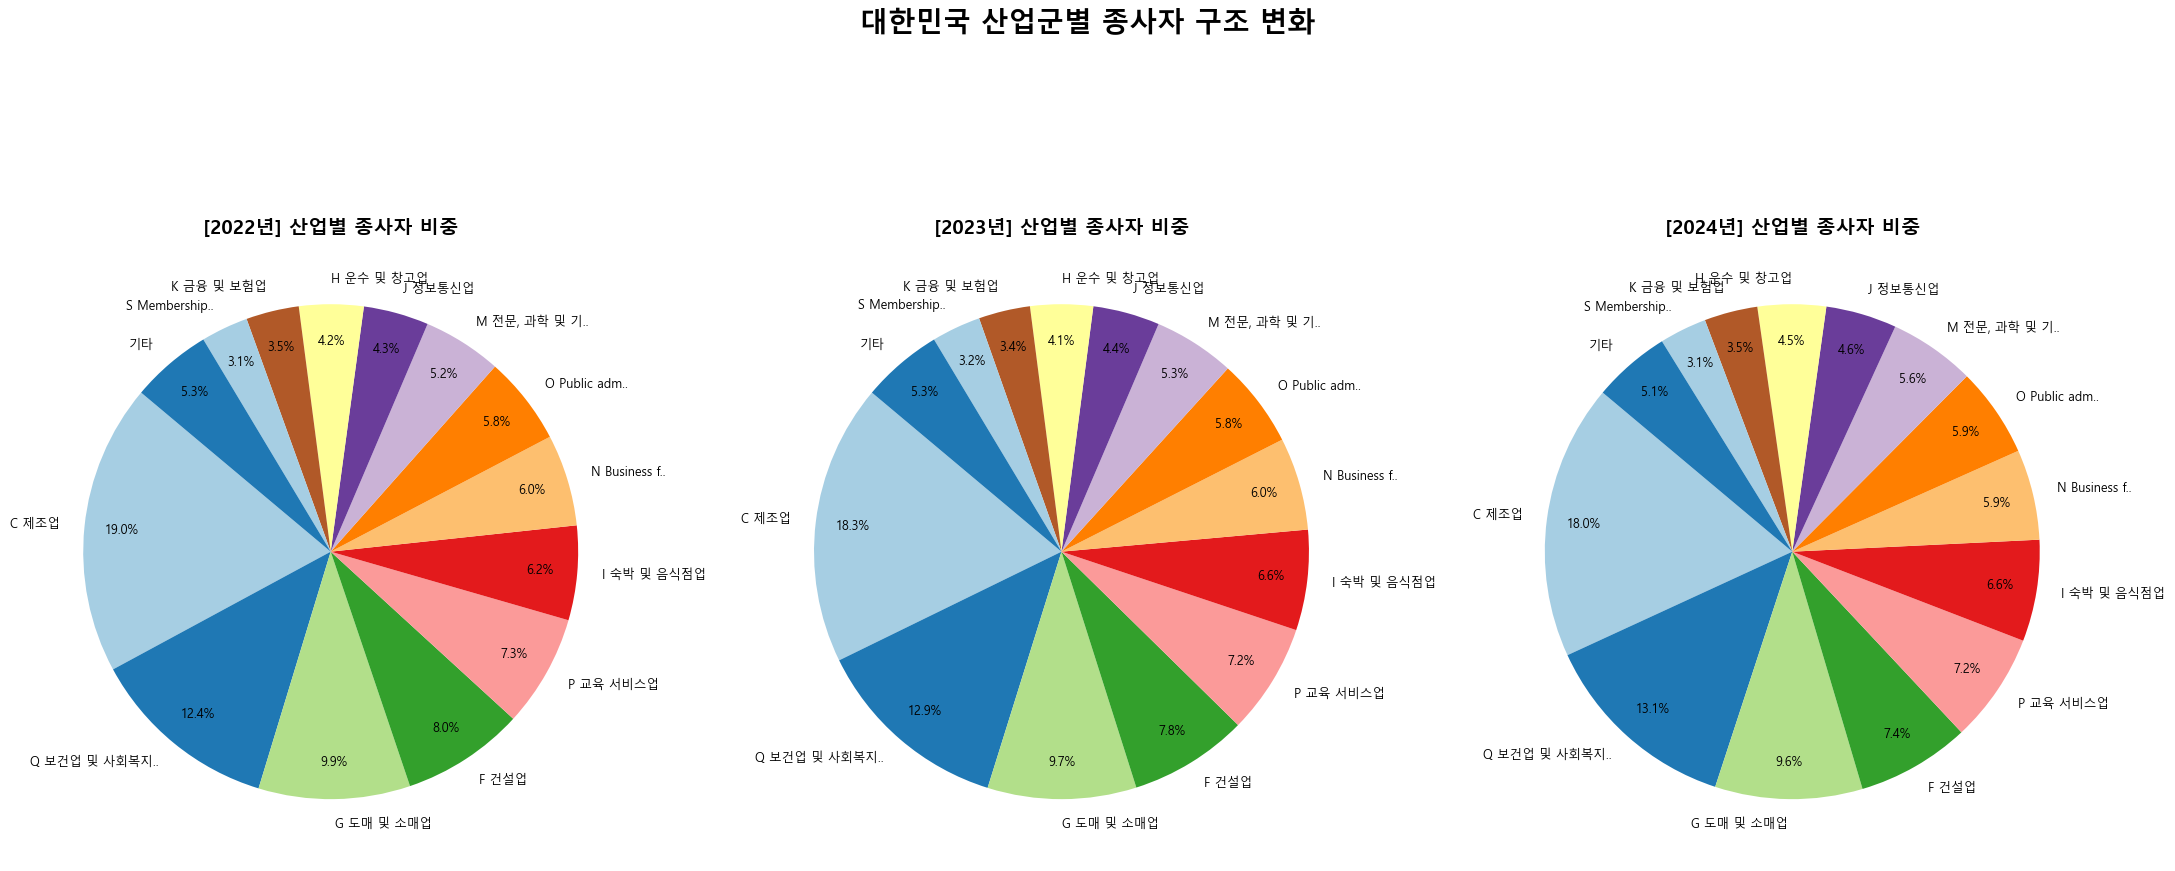

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_yearly_industry_pies_grouped():
    # 1. 데이터 불러오기
    file_name = '산업별_연도별_원지수_추출.csv'
    try:
        df = pd.read_csv(file_name, encoding='utf-8-sig')
    except:
        df = pd.read_csv(file_name, encoding='cp949')

    # 2. 데이터 정제: 21개 주요 산업 대분류(A~U)만 필터링
    df_clean = df[df['산업별'].str.contains(r'^[A-U]\s', regex=True)].copy()
    
    # 3. 그래프 설정 (한글 폰트)
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

    # 4. 3개의 서브플롯 생성 (2022, 2023, 2024)
    years = ['2022년', '2023년', '2024년']
    fig, axes = plt.subplots(1, 3, figsize=(22, 10))
    
    threshold = 0.02  # 2% 기준 설정

    for i, year in enumerate(years):
        col_name = f"{year} 원지수"
        
        # 현재 연도의 데이터와 라벨 추출
        year_data = df_clean[col_name].values
        year_labels = df_clean['산업별'].values
        
        # 비율 계산
        total = year_data.sum()
        ratios = year_data / total
        
        # 2% 이상인 항목과 미만인 항목 분리
        mask = ratios >= threshold
        
        # 2% 이상인 데이터
        final_values = year_data[mask].tolist()
        final_labels = [label[:12] + '..' if len(label) > 12 else label for label in year_labels[mask]]
        
        # 2% 미만인 데이터 합산하여 '기타'로 추가
        others_sum = year_data[~mask].sum()
        if others_sum > 0:
            final_values.append(others_sum)
            final_labels.append("기타")
        
        # 파이차트 그리기
        axes[i].pie(final_values, labels=final_labels, autopct='%1.1f%%', startangle=140, 
                    colors=plt.cm.Paired.colors, textprops={'fontsize': 9},
                    pctdistance=0.85, labeldistance=1.1)
        axes[i].set_title(f'[{year}] 산업별 종사자 비중', fontsize=14, fontweight='bold')

    plt.suptitle('대한민국 산업군별 종사자 구조 변화', fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()

    # 5. 결과 저장 및 출력
    output_img = '산업별_연도별_비중_파이차트_그룹화.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ 2% 미만 항목이 '기타'로 통합된 파이차트가 '{output_img}'로 저장되었습니다.")
    plt.show()

if __name__ == "__main__":
    plot_yearly_industry_pies_grouped()

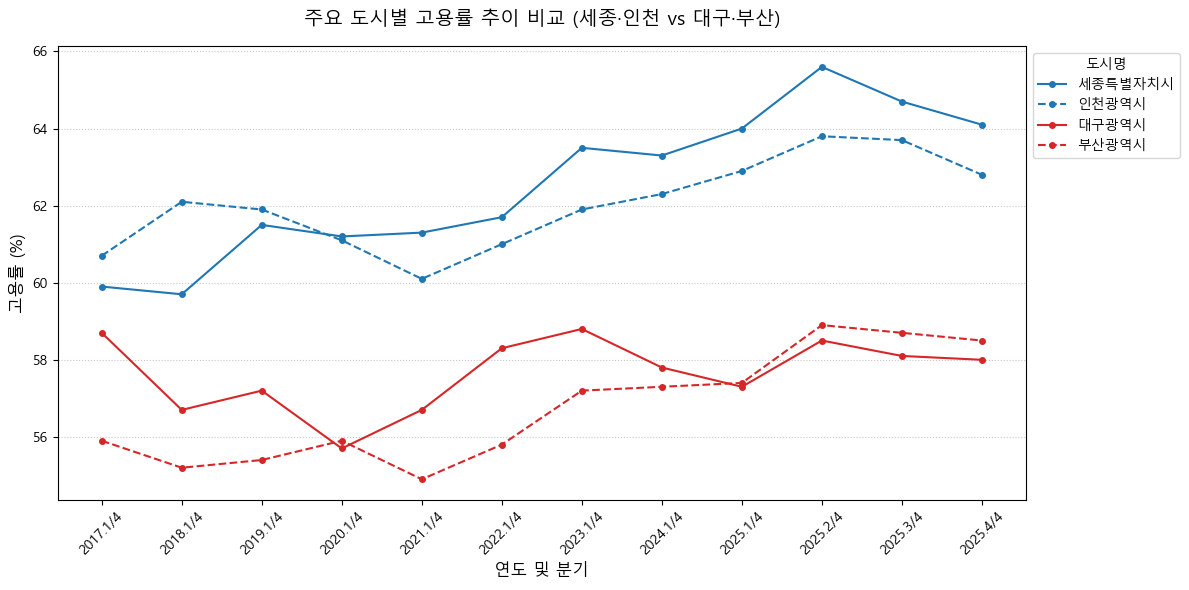

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# 1. 시스템에 따른 한글 폰트 자동 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'   
else:
    plt.rcParams['font.family'] = 'NanumGothic'    

# 마이너스 기호가 깨지는 현상 방지
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 (파일 이름 확인 필요)
file_name = '행정구역_시도__연령별_경제활동인구_20260317133046.csv'
try:
    df = pd.read_csv(file_name, encoding='utf-8')
except:
    df = pd.read_csv(file_name, encoding='euc-kr')

# 3. 데이터 필터링 및 전처리
target_cities = ['세종특별자치시', '인천광역시', '대구광역시', '부산광역시']
df_filtered = df[(df['시도별'].isin(target_cities)) & (df['연령계층별'] == '계')].copy()

# 고용률 데이터 추출 
cols = [col for col in df.columns if '/' in col]
df_plot = df_filtered[['시도별'] + cols].set_index('시도별').T
df_plot = df_plot.apply(pd.to_numeric)

# 4. 그래프 시각화
config = {
    '세종특별자치시': {'color': 'tab:blue', 'ls': '-'},
    '인천광역시': {'color': 'tab:blue', 'ls': '--'},
    '대구광역시': {'color': 'tab:red', 'ls': '-'},
    '부산광역시': {'color': 'tab:red', 'ls': '--'}
}

plt.figure(figsize=(12, 6))

for city in target_cities:
    if city in df_plot.columns:
        plt.plot(df_plot.index, df_plot[city], 
                 label=city, 
                 color=config[city]['color'], 
                 linestyle=config[city]['ls'],
                 marker='o', markersize=4)

plt.title('주요 도시별 고용률 추이 비교 (세종·인천 vs 대구·부산)', fontsize=14, pad=15)
plt.xlabel('연도 및 분기', fontsize=12)
plt.ylabel('고용률 (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='도시명', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()

# 그래프 저장 및 출력
plt.savefig('city_employment_comparison_fixed.png')
plt.show()